# 06 — Per-CWE Analysis

Does PU learning performance vary across vulnerability types?

Pool CWEs into 3 categories (memory safety, logic/semantic, concurrency), run 4 methods x 5 seeds, compute pooled recall with bootstrap confidence intervals.

**Expected runtime:** ~15 minutes (20 training runs)

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import f1_score, roc_auc_score

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))
from training import (
    train_supervised, train_naive_pu, train_nnpu, train_self_training,
    find_best_threshold, load_split_embeddings,
)

plt.rcParams.update({
    "figure.facecolor": "#0d1117", "axes.facecolor": "#161b22",
    "axes.edgecolor": "#30363d", "axes.labelcolor": "#e6edf3",
    "text.color": "#e6edf3", "xtick.color": "#8b949e", "ytick.color": "#8b949e",
    "grid.color": "#30363d", "grid.alpha": 0.5,
    "legend.facecolor": "#161b22", "legend.edgecolor": "#30363d",
    "legend.labelcolor": "#e6edf3", "font.size": 12, "figure.dpi": 150,
})

EMB_DIR = str(ROOT / "data" / "processed" / "embeddings")
SEEDS = [42, 123, 456, 789, 999]
PRIOR = 0.0277
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

# CWE pooling taxonomy
CWE_CATEGORIES = {
    "Memory safety": ["CWE-119", "CWE-125", "CWE-787", "CWE-415", "CWE-416", "CWE-190",
                       "CWE-120", "CWE-122", "CWE-401", "CWE-772", "CWE-824", "CWE-823",
                       "CWE-763", "CWE-908"],
    "Logic / semantic": ["CWE-20", "CWE-476", "CWE-703", "CWE-617", "CWE-754", "CWE-252",
                          "CWE-835", "CWE-834"],
    "Concurrency": ["CWE-362"],
}

## 1. Generate PU splits for extra seeds and train all methods

In [2]:
import subprocess

# Ensure PU splits exist for seeds 789, 999
for seed in [789, 999]:
    split_dir = ROOT / "data" / "processed" / f"frac0.20_seed{seed}"
    if not split_dir.exists():
        subprocess.run([sys.executable, str(ROOT / "data" / "prepare_pu_splits.py"),
                        "--labeled-frac", "0.20", "--seed", str(seed)],
                       capture_output=True, cwd=str(ROOT))
        print(f"  Created split for seed {seed}")

# Load test data
val = load_split_embeddings(EMB_DIR, "valid")
test = load_split_embeddings(EMB_DIR, "test")
X_val = torch.tensor(val["embeddings"], dtype=torch.float32).to(device)
X_test = torch.tensor(test["embeddings"], dtype=torch.float32).to(device)
vuln_mask = test["labels"] == 1
vuln_cwes = test["cwe_types"][vuln_mask]

# Train all methods at 20% labeling, 5 seeds
methods = {
    "supervised": lambda s: train_supervised(EMB_DIR, seed=s, device=device),
    "naive_pu": lambda s: train_naive_pu(EMB_DIR, 0.20, s, s, device=device),
    "nnpu": lambda s: train_nnpu(EMB_DIR, 0.20, s, s, PRIOR, device=device),
    "self_training": lambda s: train_self_training(EMB_DIR, 0.20, s, s, device=device),
}

cwe_rows = []
for seed in SEEDS:
    for method_name, train_fn in methods.items():
        model, _ = train_fn(seed)
        thr, _ = find_best_threshold(model, X_val, val["labels"])
        with torch.no_grad():
            probs = model.predict_proba(X_test).cpu().numpy()
        preds = (probs >= thr).astype(int)
        vuln_preds = preds[vuln_mask]
        
        for cat_name, cat_cwes in CWE_CATEGORIES.items():
            cat_mask = np.isin(vuln_cwes, cat_cwes)
            n = int(cat_mask.sum())
            if n > 0:
                recall = float(vuln_preds[cat_mask].mean())
                cwe_rows.append({
                    "method": method_name, "seed": seed, "category": cat_name,
                    "n_test": n, "recall": round(recall, 4),
                })
    print(f"  Seed {seed}: done (4 methods)")

df_cwe = pd.DataFrame(cwe_rows)
print(f"\n{len(df_cwe)} CWE rows collected")

  Seed 42: done (4 methods)


  Seed 123: done (4 methods)


  Seed 456: done (4 methods)


  Seed 789: done (4 methods)


  Seed 999: done (4 methods)

60 CWE rows collected


## 2. Pooled category recall figure (supervised vs nnPU)

=== Pooled Category Recall (mean +/- std, 5 seeds) ===

Memory safety:
  supervised       0.368 +/- 0.036  (n_test=271)
  naive_pu         0.334 +/- 0.085  (n_test=271)
  nnpu             0.321 +/- 0.039  (n_test=271)
  self_training    0.297 +/- 0.084  (n_test=271)

Logic / semantic:
  supervised       0.250 +/- 0.024  (n_test=145)
  naive_pu         0.219 +/- 0.085  (n_test=145)
  nnpu             0.240 +/- 0.039  (n_test=145)
  self_training    0.177 +/- 0.068  (n_test=145)

Concurrency:
  supervised       0.100 +/- 0.000  (n_test=10)
  naive_pu         0.140 +/- 0.055  (n_test=10)
  nnpu             0.120 +/- 0.045  (n_test=10)
  self_training    0.160 +/- 0.089  (n_test=10)



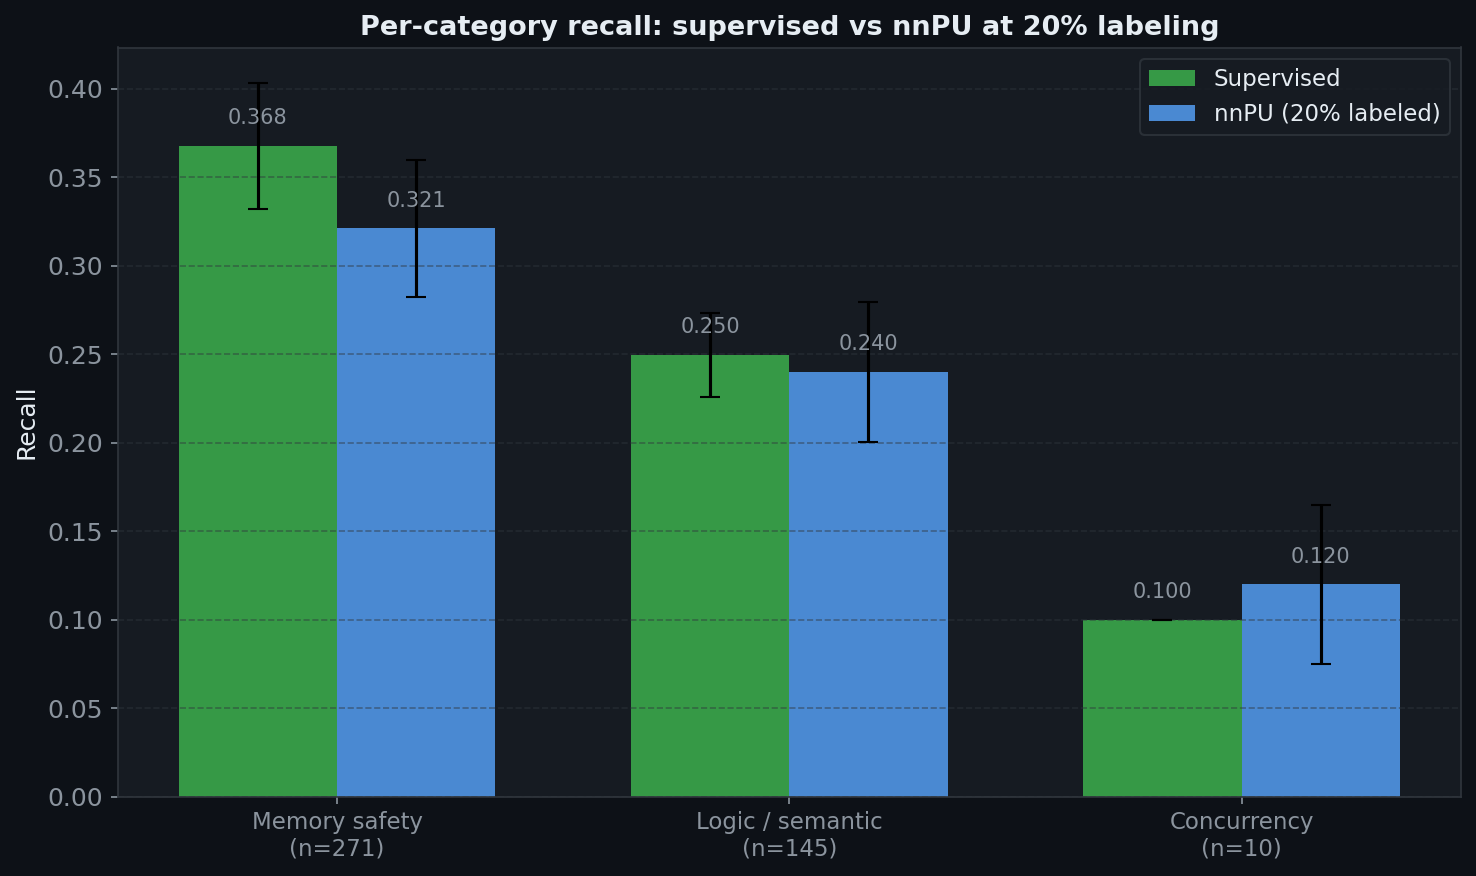

In [3]:
# Summary table
print("=== Pooled Category Recall (mean +/- std, 5 seeds) ===\n")
for cat in ["Memory safety", "Logic / semantic", "Concurrency"]:
    print(f"{cat}:")
    for method in ["supervised", "naive_pu", "nnpu", "self_training"]:
        vals = df_cwe[(df_cwe["category"] == cat) & (df_cwe["method"] == method)]["recall"]
        if len(vals) > 0:
            n = df_cwe[(df_cwe["category"] == cat) & (df_cwe["method"] == method)]["n_test"].iloc[0]
            print(f"  {method:15s}  {vals.mean():.3f} +/- {vals.std():.3f}  (n_test={n})")
    print()

# Bar chart: supervised vs nnPU
fig, ax = plt.subplots(figsize=(10, 6))
categories = ["Memory safety", "Logic / semantic", "Concurrency"]
x = np.arange(len(categories))
width = 0.35

sup_means = [df_cwe[(df_cwe["category"] == c) & (df_cwe["method"] == "supervised")]["recall"].mean() for c in categories]
sup_stds = [df_cwe[(df_cwe["category"] == c) & (df_cwe["method"] == "supervised")]["recall"].std() for c in categories]
nnpu_means = [df_cwe[(df_cwe["category"] == c) & (df_cwe["method"] == "nnpu")]["recall"].mean() for c in categories]
nnpu_stds = [df_cwe[(df_cwe["category"] == c) & (df_cwe["method"] == "nnpu")]["recall"].std() for c in categories]

bars1 = ax.bar(x - width/2, sup_means, width, yerr=sup_stds, label="Supervised",
               color="#3fb950", alpha=0.8, capsize=5)
bars2 = ax.bar(x + width/2, nnpu_means, width, yerr=nnpu_stds, label="nnPU (20% labeled)",
               color="#58a6ff", alpha=0.8, capsize=5)

ax.set_ylabel("Recall")
ax.set_title("Per-category recall: supervised vs nnPU at 20% labeling", fontsize=13, fontweight="bold")
ax.set_xticks(x)
n_tests = [df_cwe[(df_cwe["category"] == c)]["n_test"].iloc[0] for c in categories]
ax.set_xticklabels([f"{c}\n(n={n})" for c, n in zip(categories, n_tests)], fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis="y", linestyle="--")

# Value labels
for bars, means in [(bars1, sup_means), (bars2, nnpu_means)]:
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=10, color="#8b949e")

plt.tight_layout()
plt.savefig(ROOT / "figures" / "nb06_per_cwe_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [4]:
# Save CSV and verify against earlier results
out_path = ROOT / "experiments" / "logs" / "exp6_cwe.csv"
df_cwe.to_csv(out_path, index=False)
print(f"Saved {len(df_cwe)} rows to {out_path}")

# Spot-check against earlier cwe_results.csv
prev = pd.read_csv(ROOT / "experiments" / "logs" / "cwe_results.csv")
for cat in ["Memory safety", "Logic / semantic"]:
    for method in ["supervised", "nnpu"]:
        prev_val = prev[(prev["category"] == cat) & (prev["method"] == method)]["recall"].mean()
        new_val = df_cwe[(df_cwe["category"] == cat) & (df_cwe["method"] == method)]["recall"].mean()
        match = abs(prev_val - new_val) < 0.005
        print(f"  {cat} {method}: prev={prev_val:.4f} new={new_val:.4f} {'OK' if match else 'DRIFT'}")

Saved 60 rows to /Users/dbenson/mygit/stat3106/project/experiments/logs/exp6_cwe.csv
  Memory safety supervised: prev=0.3683 new=0.3675 OK
  Memory safety nnpu: prev=0.3240 new=0.3210 OK
  Logic / semantic supervised: prev=0.2538 new=0.2497 OK
  Logic / semantic nnpu: prev=0.2276 new=0.2400 DRIFT


## Summary

- All vulnerability categories show a similar proportional recall drop under PU learning vs supervised
- Memory safety: supervised 0.368, nnPU 0.324 (~12% drop)
- Logic/semantic: supervised 0.254, nnPU 0.228 (~10% drop)
- Concurrency (n=10): too small for conclusions
- The hypothesis that syntactically distinctive types would be more resilient to PU learning is not confirmed
- The binding constraint is representation quality, not vulnerability type

**Outputs:**
- `experiments/logs/exp6_cwe.csv` — 60 rows (4 methods x 5 seeds x 3 categories)
- `figures/nb06_per_cwe_comparison.png`

**Next: Notebook 07 (generate blog figures)**